## Кейс №1

### Препарат Х, снижающий уровень гликемии



Библиотеки:

In [1]:
import pandas as pd
import numpy as np
from itertools import product
from math import ceil



Константы:

In [2]:
RS = 1000

Функции:

Создаем таблицу с данными:

In [24]:
# Параметры датасета
np.random.seed(RS)  # для воспроизводимости
n = 1000  # общее количество наблюдений

# Создаем базовый датафрейм
df = pd.DataFrame({
    'Group': ['Trt'] * (n//2) + ['Ctrl'] * (n//2)
})

# Добавляем возрастные группы с разными вероятностями для каждой группы
def assign_age_group(group):
    if group == 'Trt':
        return np.random.choice(['18-39', '40-65', '65 +'], 
                               p=[0.6, 0.2, 0.2])
    else:
        return np.random.choice(['18-39', '40-65', '65 +'], 
                               p=[0.3, 0.4, 0.3])

df['Age_Group'] = df['Group'].apply(assign_age_group)

# Добавляем пол (равномерное распределение)
df['Gender'] = np.random.choice(['Мужчина', 'Женщина'], size=n)

# Функция для генерации роста в зависимости от пола и возраста
def generate_height(gender, age_group):
    if gender == 'Мужчина':
        if age_group == '18-39':
            mean_height = 178
            std_height = 7
        elif age_group == '40-65':
            mean_height = 176
            std_height = 6
        else:  # 65 +
            mean_height = 173
            std_height = 6
    else:  # Женщина
        if age_group == '18-39':
            mean_height = 165
            std_height = 6
        elif age_group == '40-65':
            mean_height = 163
            std_height = 5
        else:  # 65 +
            mean_height = 160
            std_height = 5
    
    height = np.random.normal(mean_height, std_height)
    return round(max(150, min(210, height)))  # ограничиваем разумные пределы

# Функция для генерации веса в зависимости от пола, возраста и роста
def generate_weight(gender, age_group, height):
    # Рассчитываем идеальный вес по формуле Девина
    if gender == 'Мужчина':
        ideal_weight = 50 + 0.9 * (height - 152)
    else:
        ideal_weight = 45.5 + 0.9 * (height - 152)
    
    # Добавляем вариацию в зависимости от возраста
    if age_group == '18-39':
        weight_variation = np.random.normal(0, 8)
    elif age_group == '40-65':
        weight_variation = np.random.normal(5, 10)  # немного выше в среднем возрасте
    else:  # 65 +
        weight_variation = np.random.normal(-2, 9)  # немного ниже в пожилом возрасте
    
    weight = ideal_weight + weight_variation
    return round(max(40, min(150, weight)), 1)  # ограничиваем разумные пределы

# Генерируем рост
df['Рост, см'] = df.apply(lambda row: generate_height(row['Gender'], row['Age_Group']), axis=1)

# Генерируем вес
df['Вес, кг'] = df.apply(lambda row: generate_weight(row['Gender'], row['Age_Group'], row['Рост, см']), axis=1)

# Рассчитываем ИМТ
df['ИМТ, кг/м²'] = round(df['Вес, кг'] / ((df['Рост, см'] / 100) ** 2), 1)

# Базовая гликемия (исходный уровень)
base_glucose = 5.0

# Визит 1 - Гликемия
def calculate_visit1_glucose(row):
    glucose = base_glucose
    
    # Возрастной эффект (+2 ммоль для старших возрастных групп)
    if row['Age_Group'] in ['40-65', '65 +']:
        glucose += 2
    
    # Гендерный эффект (+2 ммоль для мужчин в старших возрастных группах)
    if row['Gender'] == 'Мужчина' and row['Age_Group'] in ['40-65', '65 +']:
        glucose += 2
    
    # Небольшой эффект от ИМТ
    glucose += (row['ИМТ, кг/м²'] - 25) * 0.1
    
    # Добавляем случайный шум
    glucose += np.random.normal(0, 0.5)
    
    return round(glucose, 1)

df['Визит 1 - Гликемия, ммоль/л'] = df.apply(calculate_visit1_glucose, axis=1)

# Визит 2 - Гликемия
def calculate_visit2_glucose(row):
    glucose = base_glucose
    
    # Возрастной эффект (+1 ммоль для старших возрастных групп)
    if row['Age_Group'] in ['40-65', '65 +']:
        glucose += 1
    
    # Гендерный эффект (+1 ммоль для мужчин в старших возрастных группах)
    if row['Gender'] == 'Мужчина' and row['Age_Group'] in ['40-65', '65 +']:
        glucose += 1
    
    # Эффект группы (+2 ммоль для Ctrl)
    if row['Group'] == 'Ctrl':
        glucose += 2
    
    # Небольшой эффект от ИМТ
    glucose += (row['ИМТ, кг/м²'] - 25) * 0.1
    
    # Добавляем случайный шум
    glucose += np.random.normal(0, 0.5)
    
    return round(glucose, 1)

df['Визит 2 - Гликемия, ммоль/л'] = df.apply(calculate_visit2_glucose, axis=1)

# Перемешиваем данные
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


Прямой анализ таблицы

In [4]:
import numpy as np
import pandas as pd
from itertools import product
from math import ceil

def stratified_randomisation(n_subjects: int,
                             group_ratio,
                             strata_probs: dict,
                             *,
                             exact_strata_counts: bool = False,
                             seed: int | None = None):
    """
    Parameters
    ----------
    …
    exact_strata_counts : bool (default False)
        • False  → sample strata independently, multinomially  (old behaviour)
        • True   → create the precise *expected* counts for each
                    stratum combination (quota sampling)

    Returns
    -------
    assignments : pd.DataFrame
    summary      : dict (same keys as before)
    """
    rng = np.random.default_rng(seed)

    # --------------------- group handling --------------------------------
    ratio = np.asarray(group_ratio, dtype=float)
    if np.isclose(ratio.sum(), 1.0):  # user provided probabilities
        ratio = ratio / np.min(ratio)
    n_groups   = len(ratio)
    grp_labels = [f"Group_{i+1}" for i in range(n_groups)]
    blocksize  = int(ratio.sum())

    # --------------------- build strata grid -----------------------------
    strata_cols = list(strata_probs.keys())
    strata_levels = [list(levels) for levels in
                     (prob_dict.keys() for prob_dict in strata_probs.values())]

    strata_df = pd.DataFrame(list(product(*strata_levels)),
                             columns=strata_cols)

    # Add probabilities (assuming independence)
    prob = np.ones(len(strata_df), dtype=float)
    for col in strata_cols:
        prob *= strata_df[col].map(strata_probs[col]).values
    strata_df['prob'] = prob

    # Determine counts for each combination ------------------------------
    if exact_strata_counts:
        # Exact expected counts (using largest remainder to guarantee sum)
        exact_raw = n_subjects * strata_df['prob'].values
        base      = np.floor(exact_raw).astype(int)
        remainder = exact_raw - base
        missing   = n_subjects - base.sum()

        # distribute remaining subjects to cells with largest fractional part
        if missing:
            add_idx = np.argsort(-remainder)[:missing]
            base[add_idx] += 1
        cell_counts = base
    else:
        # Multinomial draw
        cell_counts = rng.multinomial(n_subjects, strata_df['prob'].values)

    strata_df['n'] = cell_counts
    assert strata_df['n'].sum() == n_subjects

    # --------------------- expand subjects -------------------------------
    df_list = []
    subj_id = 1
    for _, row in strata_df.iterrows():
        if row['n'] == 0:
            continue
        block = pd.DataFrame({
            'Subject': np.arange(subj_id, subj_id + row['n'])
        })
        for col in strata_cols:
            block[col] = row[col]
        df_list.append(block)
        subj_id += row['n']

    df = pd.concat(df_list, ignore_index=True)

    # --------------------- group allocation ------------------------------
    df['Group'] = None
    for combo_vals, idx in df.groupby(strata_cols, sort=False).groups.items():
        n_combo = len(idx)
        n_blocks = ceil(n_combo / blocksize)
        sequence = []
        for _ in range(n_blocks):
            block = np.concatenate([[lab] * int(rep)
                                    for lab, rep in zip(grp_labels, ratio)])
            rng.shuffle(block)
            sequence.extend(block)
        df.loc[idx, 'Group'] = sequence[:n_combo]

    # --------------------- summaries -------------------------------------
    grp_counts = (df['Group']
                  .value_counts()
                  .rename_axis('Group')
                  .reset_index(name='n'))

    str_counts = {s: (df[s]
                      .value_counts()
                      .rename_axis(s)
                      .reset_index(name='n'))
                  for s in strata_cols}

    rand_lists = {combo: list(df.loc[idx]
                              .sort_values('Subject')['Group'].values)
                  for combo, idx in df.groupby(strata_cols,
                                               sort=False).groups.items()}

    summary = dict(total_n      = n_subjects,
                   group_counts = grp_counts,
                   strata_counts= str_counts,
                   rand_lists   = rand_lists)

    return df, summary

In [5]:
strata = {
    "Sex":        {"Male": .5,  "Female": .5},
    "Age group":  {"18-39": .5, "40-65": .3, "65+": .2}
}

assignments, info = stratified_randomisation(
                       n_subjects = 300,
                       group_ratio= [.8, .2],
                       strata_probs=strata,
                       exact_strata_counts=True,  # <── key line
                       seed=2024)

print(assignments.drop('Subject', axis=1)
                  .groupby(['Sex', 'Age group', 'Group'])
                  .size())

Sex     Age group  Group  
Female  18-39      Group_1    60
                   Group_2    15
        40-65      Group_1    36
                   Group_2     9
        65+        Group_1    24
                   Group_2     6
Male    18-39      Group_1    60
                   Group_2    15
        40-65      Group_1    36
                   Group_2     9
        65+        Group_1    24
                   Group_2     6
dtype: int64


In [6]:
assignments.drop('Subject', axis = 'columns').groupby(['Sex',	'Age group',	'Group']).value_counts()

Sex     Age group  Group  
Female  18-39      Group_1    60
                   Group_2    15
        40-65      Group_1    36
                   Group_2     9
        65+        Group_1    24
                   Group_2     6
Male    18-39      Group_1    60
                   Group_2    15
        40-65      Group_1    36
                   Group_2     9
        65+        Group_1    24
                   Group_2     6
Name: count, dtype: int64

25.0

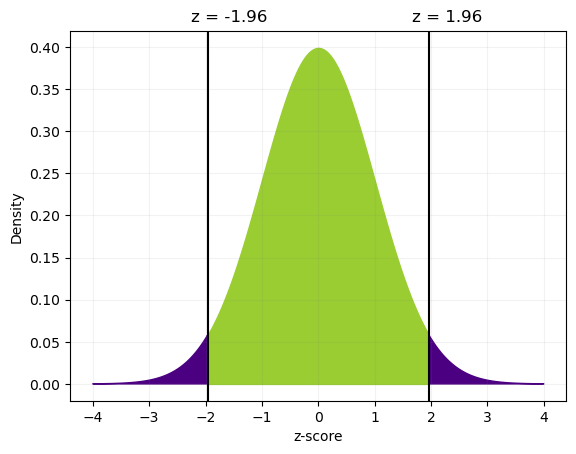

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# x values
x = np.linspace(-4, 4, 1000)

# standard normal pdf values
pdf = norm.pdf(x, 0, 1)

# z cutoff
z_l = -1.96
z_u = 1.96

# plot shaded areas
plt.grid(c = 'gray', alpha = 0.1)
plt.fill_between(x, pdf, where=((x <= z_l) | (x >= z_u)), color='indigo')  # left shaded region
plt.fill_between(x, pdf, where=((x > z_l) & (x < z_u)), color='yellowgreen')  # right shaded region

# vertical line at z
plt.axvline(z_l, color='black')
plt.axvline(z_u, color='black')

# annotation text
plt.text(z_l - 0.3, 0.43, 'z = ' + str(z_l), fontsize=12)
plt.text(z_u - 0.3, 0.43, 'z = ' + str(z_u), fontsize=12)

# axis labels
plt.xlabel('z-score')
plt.ylabel('Density')

plt.show()
